<a href="https://colab.research.google.com/github/Andrian0s/ML4NLP1-2026-Tutorial-Notebooks/blob/main/exercises/ex1/ex1_lr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML4NLP1

## Starting Point for Exercise 1, part I

This notebook is supposed to serve as a starting point and/or inspiration when starting exercise 1, part I.

One of the goals of this exercise is to get you acquainted with sklearn and related libraries like pandas and numpy. You will probably need to consult the documentation of those libraries:
- sklearn: [Documentation](https://scikit-learn.org/stable/user_guide.html)
- Pandas: [Documentation](https://pandas.pydata.org/docs/#)
- NumPy: [Documentation](https://numpy.org/doc/)
- SHAP: [Documentation](https://shap.readthedocs.io/en/latest/index.html)

## Task Description

Follow the instructions in this notebook to:

1. Explore the data and create training/test splits for your experiments

2. Build a LogisticRegression classifier and design some relevant features to apply it to your data

3. Conduct hyperparameter tuning to find the optimal hyperparameters for your model

4. Explore your model's predictions and conduct an error analysis to see where the model fails

5. Conduct an interpretability analysis, investigating the model's most important features.

6. Conduct an ablation study using a subset of languages


Throughout the notebook, there are questions that you should address in your report. These are marked with 📝❓ and are collected again in the lab report section at the end of the notebook.

☝ Note, these questions are intended to provide you with an opportunity to reflect on what it is that you are doing and the kind of challenges you might face along the way.

## Use of generative AI

AI tools may be used in this exercise to help you explain code, debug, improve documentation, and explore alternatives. Any use must be documented in the *Declaration on the use of AI* at the end of this notebook (which tools were used and for which purposes). You remain responsible for understanding, checking, and testing everything you submit, and you must be able to explain any submitted text, code, analyses, and AI-assisted contributions. See the [CL guidelines on academic integrity and AI use](https://www.cl.uzh.ch/en/Studies/Services/academic-integrity.html).

In [2]:
# Pin the library versions used in this course (the same ones as in the W03 tutorial),
# so that your notebook runs the same way for you and for your reviewers.
%pip install -q scikit-learn==1.9.1 shap==0.52.0 gdown matplotlib

import sklearn, shap
print(f"scikit-learn {sklearn.__version__} | shap {shap.__version__}")

Note: you may need to restart the kernel to use updated packages.


/Users/bdonick/Desktop/uzh/f26/nlp/exercises/ml_nlp/exercise1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scikit-learn 1.9.1 | shap 0.52.0


In [4]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

### Loading the datasets

In [5]:
# Download dataset
!gdown 1QP6YuwdKFNUPpvhOaAcvv2Pcp4JMbIRs # x_train
!gdown 1QVo7PZAdiZKzifK8kwhEr_umosiDCUx6 # x_test
!gdown 1QbBeKcmG2ZyAEFB3AKGTgSWQ1YEMn2jl # y_train
!gdown 1QaZj6bI7_78ymnN8IpSk4gVvg-C9fA6X # y_test

Downloading...
From: https://drive.google.com/uc?id=1QP6YuwdKFNUPpvhOaAcvv2Pcp4JMbIRs
To: /Users/bdonick/Desktop/uzh/f26/nlp/exercises/ml_nlp/exercise1/x_train.txt
100%|██████████████████████████████████████| 64.1M/64.1M [00:00<00:00, 153MB/s]
Using cookies from /Users/bdonick/.cache/gdown/cookies.txt
Downloading...
From: https://drive.google.com/uc?id=1QVo7PZAdiZKzifK8kwhEr_umosiDCUx6
To: /Users/bdonick/Desktop/uzh/f26/nlp/exercises/ml_nlp/exercise1/x_test.txt
100%|█████████████████████████████████████| 65.2M/65.2M [00:00<00:00, 96.2MB/s]
Using cookies from /Users/bdonick/.cache/gdown/cookies.txt
Downloading...
From: https://drive.google.com/uc?id=1QbBeKcmG2ZyAEFB3AKGTgSWQ1YEMn2jl
To: /Users/bdonick/Desktop/uzh/f26/nlp/exercises/ml_nlp/exercise1/y_train.txt
100%|███████████████████████████████████████| 480k/480k [00:00<00:00, 11.6MB/s]
Using cookies from /Users/bdonick/.cache/gdown/cookies.txt
Downloading...
From: https://drive.google.com/uc?id=1QaZj6bI7_78ymnN8IpSk4gVvg-C9fA6X
To: /U

In [6]:
with open('x_train.txt') as f:
    x_train = f.read().splitlines()
with open('y_train.txt') as f:
    y_train = f.read().splitlines()
with open('x_test.txt') as f:
    x_test = f.read().splitlines()
with open('y_test.txt') as f:
    y_test = f.read().splitlines()

In [7]:
# Combine x_train and y_train into one dataframe
train_df = pd.DataFrame({'text': x_train, 'label': y_train})
# Combine x_test and y_test into one dataframe
test_df = pd.DataFrame({'text': x_test, 'label': y_test})
# Inspect the first 5 items in the train split
train_df.head()

,text,label
0,Klement Gottwaldi surnukeha palsameeriti ning ...,est
1,"Sebes, Joseph; Pereira Thomas (1961) (på eng)....",swe
2,भारतीय स्वातन्त्र्य आन्दोलन राष्ट्रीय एवम क्षे...,mai
3,"Après lo cort periòde d'establiment a Basilèa,...",oci
4,ถนนเจริญกรุง (อักษรโรมัน: Thanon Charoen Krung...,tha


In [8]:
# Get list of all labels
labels = train_df['label'].unique().tolist()
print(labels)

['est', 'swe', 'mai', 'oci', 'tha', 'orm', 'lim', 'guj', 'pnb', 'zea', 'krc', 'hat', 'pcd', 'tam', 'vie', 'pan', 'szl', 'ckb', 'fur', 'wuu', 'arz', 'ton', 'eus', 'map-bms', 'glk', 'nld', 'bod', 'jpn', 'arg', 'srd', 'ext', 'sin', 'kur', 'che', 'tuk', 'pag', 'tur', 'als', 'koi', 'lat', 'urd', 'tat', 'bxr', 'ind', 'kir', 'zh-yue', 'dan', 'por', 'fra', 'ori', 'nob', 'jbo', 'kok', 'amh', 'khm', 'hbs', 'slv', 'bos', 'tet', 'zho', 'kor', 'sah', 'rup', 'ast', 'wol', 'bul', 'gla', 'msa', 'crh', 'lug', 'sun', 'bre', 'mon', 'nep', 'ibo', 'cdo', 'asm', 'grn', 'hin', 'mar', 'lin', 'ile', 'lmo', 'mya', 'ilo', 'csb', 'tyv', 'gle', 'nan', 'jam', 'scn', 'be-tarask', 'diq', 'cor', 'fao', 'mlg', 'yid', 'sme', 'spa', 'kbd', 'udm', 'isl', 'ksh', 'san', 'aze', 'nap', 'dsb', 'pam', 'cym', 'srp', 'stq', 'tel', 'swa', 'vls', 'mzn', 'bel', 'lad', 'ina', 'ava', 'lao', 'min', 'ita', 'nds-nl', 'oss', 'kab', 'pus', 'fin', 'snd', 'kaa', 'fas', 'cbk', 'cat', 'nci', 'mhr', 'roa-tara', 'frp', 'ron', 'new', 'bar', 'ltg'


### 1.1 Exploring the training data

📝❓ Take a look at a couple of texts from different languages and answer the following questions:

1. Do you notice anything that might be challenging for the classification?
2. How is the data distributed? (i.e., how many instances per label are there in the training and test set? Is it a balanced dataset?)
3. Do you think the train/test split is appropriate (i.e., is the test data representative of the training data)? If not, please rearrange the data in a more appropriate way.


In [13]:
# TODO: Inspect the training data

'''
1. Similar languages (dan, nob, nno, swe) share words and spelling, hard to tell apart.
Lots of names, numbers and foreign words that don't show the language.
Text length varies a lot, short texts give few clues.
'''

sample_langs = ['eng', 'deu', 'jpn', 'nob', 'nno', 'dan', 'swe', 'nld']

for lang in sample_langs:
    print(f"===== {lang} =====")
    examples = train_df[train_df['label'] == lang]['text'].sample(2, random_state=42)
    for text in examples:
        print(text[:100])
        print('---')
    print()

'''
2. 235 languages, 500 texts each in train and in test, balanced.
'''

print(train_df.shape, test_df.shape)
print(train_df['label'].value_counts().describe())
print(test_df['label'].value_counts().describe())

'''
3. Test matches train (same labels, counts, text lengths), so it is representative.
50/50 train test split is too much test, changing to 80/20.
Removing duplicates in both test and train, duplicates artificially inflate test scores.
'''

print(train_df['text'].str.len().describe())
print(test_df['text'].str.len().describe())
print('texts in both splits:', len(set(train_df['text']) & set(test_df['text'])))

from sklearn.model_selection import train_test_split

all_df = pd.concat([train_df, test_df]).drop_duplicates('text')
train_df, test_df = train_test_split(all_df, test_size=0.2, stratify=all_df['label'], random_state=42)
print(train_df.shape, test_df.shape)


===== eng =====
After Schmidt announced the end of his tenure as CEO on January 20, 2011, he jokingly tweeted on Twi
---
Hearst's bail was revoked in May 1978 when appeals failed and the Supreme Court declined to hear her
---

===== deu =====
Die Kirchenruine zum Heiligen Grabe, auch als Schöntalruine bekannt, ist die Ruine der 1543 bis 1545
---
Girja nahm erstmals an einer Schacholympiade 2010 mit der zweiten russischen Frauenmannschaft teil. 
---

===== jpn =====
AE100形 - 2代目スカイライナー用車両。成田スカイアクセス非対応で、2010年7月17日からは「シティライナー」として運用。一部編成は2010年7月17日のダイヤ改正で運用離脱し、解体された編成
---
1740年の設立当初は、フィラデルフィアのセンターシティにキャンパスを構えていたが、1872年に現在の場所であるセンターシティからスクールキル川(英：Schuylkill River)を渡った西側にキ
---

===== nob =====
Det er ikke Goldsmiths voldsomme produksjon av populærvitenskapelig sakprosa som har gitt ham en pla
---
Harrison ble utsatt for et attentat 30. desember 1999. En psykotisk tilhenger, Michael Abram, brøt i
---

===== nno =====
Park Geun-hye (fødd 2. februar 1952) var den ellevte presidenten i Sør-Korea

### 1.2 Data preparation

Get a subset of the train/test data that includes 20 languages.
Include English (`eng`), German (`deu`), Dutch (`nld`), Danish (`dan`), Swedish (`swe`), Norwegian (either Bokmål `nob` or Nynorsk `nno`), and Japanese (`jpn`), plus 13 additional languages of your choice based on the items in the list of labels.

Note that `sklearn` classifiers accept string labels such as `'eng'` directly; the order of the classes is stored in `clf.classes_` after fitting.

In [14]:
# TODO: Create your train/test subsets of languages

'''
Required: eng, deu, nld, dan, swe, nob, jpn
Added 13: mix of similar languages (fra, spa, ita, por close to each other, fin close to est/hun)
and different scripts (rus, ell, ara, zho, kor, hin) to see how the model handles both.
'''

langs = ['eng', 'deu', 'nld', 'dan', 'swe', 'nob', 'jpn',
         'fra', 'spa', 'ita', 'por', 'fin', 'pol', 'rus',
         'ces', 'hun', 'tur', 'ell', 'ara', 'zho']

train_sub = train_df[train_df['label'].isin(langs)].reset_index(drop=True)
test_sub = test_df[test_df['label'].isin(langs)].reset_index(drop=True)

X_train, y_train = train_sub['text'], train_sub['label']
X_test, y_test = test_sub['text'], test_sub['label']

print(train_sub.shape, test_sub.shape)
print(train_sub['label'].value_counts())

(15983, 2) (3996, 2)
label
pol    800
nob    800
ita    800
nld    800
eng    800
fin    800
tur    800
zho    800
jpn    800
dan    800
deu    800
rus    799
por    799
swe    799
ces    799
ara    799
hun    799
ell    798
spa    797
fra    794
Name: count, dtype: int64


### 2.1 Build a LogisticRegression classifier

To start with, we're going to build a very simple LogisticRegression classifier.
Use a `Pipeline` to chain together a `CountVectorizer` and a `LogisticRegression` estimator. Then perform a 5-fold cross validation and report the scores of this model as a baseline.

In [15]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# TODO: Define a very basic pipeline using a CountVectorizer and a LogisticRegression classifier

'''
Baseline: word counts -> logistic regression, no tuning.
max_iter raised so the solver converges on 20 classes.
'''

pipe = Pipeline([
    ('vec', CountVectorizer()),
    ('clf', LogisticRegression(max_iter=1000))
])

In [17]:
# TODO: Run a cross validation to estimate the model's expected performance

'''
5-fold CV on the training subset, accuracy per fold and the mean.
mean accuracy: 94% - note choice scoring metric of accuracy because the classes are balanced
'''

scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
print(scores)
print('mean accuracy:', scores.mean())

[0.94401001 0.93931811 0.93587739 0.94086358 0.94336671]
mean accuracy: 0.9406871586041825



### 2.2 Feature Engineering

So far, we've only considered the basic `CountVectorizer` at the word level to encode our input texts for our model.

Your task is to apply some text preprocessing and engineer some more informative features.

To do this, think about what other features might be relevant for determining the language of an input text.

Define a custom set of feature extractors and implement the necessary preprocessing steps to extract these features from strings.

Then initialise a processing pipeline that converts your input data into features that the model can take as input.

☝ Note, this step can be as involved as your heart desires, there is only one minimal requirement: you must use something more than the base `CountVectorizer`, and your features must be different from the document statistics shown in the W03 tutorial.


In [21]:
# TODO: Data cleaning/Feature engineering steps

'''
Features:
1. char n-grams (1-3, inside word boundaries) with tf-idf
   catches spelling, word endings and accents, works on names and unseen words
2. word counts, kept from the baseline
3. custom transformer: share of characters per script + language marker letters
Preprocessing: lowercase, drop digits and punctuation. Keep accents, they tell languages apart.

Results: 
1. Took 1 min 45s to run
2. Got mean accuracy: 98.5%
'''

import re
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion


def clean(text):
    # lowercase and replace digits / punctuation / symbols with a space, accents are kept
    text = text.lower()
    text = re.sub(r'[\d\W_]+', ' ', text)
    return text


class ScriptFeatures(BaseEstimator, TransformerMixin):
    # custom sklearn transformer, same structure as TextStats in W03
    # output: one row per text, one column per script / marker group, values are shares in 0-1

    scripts = {
        'latin':    r'[a-zA-ZÀ-ÿ]',
        'cyrillic': r'[\u0400-\u04FF]',
        'greek':    r'[\u0370-\u03FF]',
        'arabic':   r'[\u0600-\u06FF]',
        'cjk':      r'[\u3040-\u30FF\u4E00-\u9FFF]',   # japanese kana + chinese characters
    }
    markers = {
        'nordic':  r'[æøå]',      # dan, nob, nno
        'swedish': r'[äö]',       # swe, fin, deu
        'german':  r'[ßü]',       # deu
        'french':  r'[éèêçàù]',   # fra, por
        'spanish': r'[ñ]',        # spa
    }

    def __init__(self):
        pass

    def fit(self, X, y=None):
        # nothing to learn from the data
        return self

    def transform(self, X):
        # for each text: count matches of each regex, divide by text length
        rows = []
        for text in X:
            n = max(len(text), 1)
            row = [len(re.findall(p, text)) / n for p in self.scripts.values()]
            row += [len(re.findall(p, text.lower())) / n for p in self.markers.values()]
            rows.append(row)
        return np.array(rows)

    def get_feature_names_out(self, input_features=None):
        # names for the columns, needed for the interpretability part later
        return np.array(list(self.scripts) + list(self.markers))


# combine the three feature sources side by side
features = FeatureUnion([
   ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(1, 3), preprocessor=clean, min_df=2)),
    ('word', CountVectorizer(preprocessor=clean)),
    ('script', ScriptFeatures()),
])

# full pipeline: features -> logistic regression
pipe_fe = Pipeline([
    ('features', features),
    ('clf', LogisticRegression(max_iter=1000)),
])

scores_fe = cross_val_score(pipe_fe, X_train, y_train, cv=5, scoring='accuracy')
print(scores_fe)
print('mean accuracy:', scores_fe.mean())


[0.98529872 0.98498592 0.98310916 0.98842303 0.98498123]
mean accuracy: 0.9853596124025849


---

### 3.1 Grid Search

Use sklearn's GridSearchCV and experiment with the following hyperparameters:
1. Regularization: its strength `C` and its type via `l1_ratio` (`l1_ratio=0` is L2, `l1_ratio=1` is L1)
2. Solver (note that not every solver supports every regularization type)
3. Experiment with parameters of the Vectorizer (optional, but highly advised)

☝ Note, don't overdo it at the beginning, since runtime might go up fast!

Make sure you read through the [docs](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) to get an understanding of what these parameters do.


In [26]:
# TODO: GridSearchCV

'''
Tuning C, l1_ratio and solver.
Only saga handles L1, lbfgs is L2 only, so two separate blocks.
First run took >90 min, saga hit max_iter=1000 on every fit without converging.
Now: saga capped at 300 iterations with looser tol, no elastic net, no ngram range in the grid.
9 combos x 3 folds = 27 fits.

Results: 
took ~25 min
best params: {'clf__C': 10, 'clf__l1_ratio': 0, 'clf__solver': 'lbfgs'}
best CV accuracy: 98.6%
'''

import time
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# time one fit first to know what we are dealing with
t0 = time.time()
pipe_fe.fit(X_train, y_train)
print(f'one lbfgs fit: {time.time() - t0:.0f} s')
print('number of features:', pipe_fe.named_steps['features'].transform(X_train[:10]).shape[1])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = [
    {   # saga: L1 and L2
        'clf__solver': ['saga'],
        'clf__max_iter': [300],
        'clf__tol': [1e-3],
        'clf__C': [0.1, 1, 10],
        'clf__l1_ratio': [0, 1],
    },
    {   # lbfgs: L2 only
        'clf__solver': ['lbfgs'],
        'clf__C': [0.1, 1, 10],
        'clf__l1_ratio': [0],
    },
]

grid = GridSearchCV(pipe_fe, param_grid, cv=cv, scoring='accuracy', n_jobs=6, verbose=1)

t0 = time.time()
grid.fit(X_train, y_train)
print(f'grid search took {time.time() - t0:.0f} s')
print('best params:', grid.best_params_)
print('best CV accuracy:', grid.best_score_)

one lbfgs fit: 17 s
number of features: 348488
Fitting 3 folds for each of 9 candidates, totalling 27 fits


/Users/bdonick/Desktop/uzh/f26/nlp/exercises/ml_nlp/exercise1/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


grid search took 1391 s
best params: {'clf__C': 10, 'clf__l1_ratio': 0, 'clf__solver': 'lbfgs'}
best CV accuracy: 0.986110300745649


### 3.2 Best Model Selection

After conducting our Grid Search, we should be able to identify our best model by inspecting the Grid Search result attribute `cv_results_`. (Hint: `cv_results_` is a dictionary, so convert it to a Pandas Dataframe for easy inspection.)

📝❓ What were the hyperparameters of your best-performing model according to cross-validation?

📝❓ What is the advantage of grid search cross-validation?


In [27]:
# TODO: Select the best model based on the GridSearch results

'''
Best model according to CV: {'clf__C': 10, 'clf__l1_ratio': 0, 'clf__solver': 'lbfgs'}
Advantage of grid search CV: tries every combination, scores each one on held-out folds,
so the pick is based on generalisation not training fit, and the test set stays untouched until the end.
The std column shows how stable each setting is across folds.
'''

results = pd.DataFrame(grid.cv_results_)

columns = ['param_clf__solver', 'param_clf__C', 'param_clf__l1_ratio',
           'mean_test_score', 'std_test_score', 'mean_fit_time', 'rank_test_score']
results = results[columns].sort_values('rank_test_score')
results.columns = [c.replace('param_clf__', '') for c in columns]
results.round(4)

,solver,C,l1_ratio,mean_test_score,std_test_score,mean_fit_time,rank_test_score
8,lbfgs,10.0,0,0.9861,0.0007,10.7388,1
7,lbfgs,1.0,0,0.9860,0.0011,12.3325,2
4,saga,10.0,0,0.9835,0.0011,42.3333,3
2,saga,1.0,0,0.9832,0.0010,39.8707,4
6,lbfgs,0.1,0,0.9827,0.0011,12.7934,5
5,saga,10.0,1,0.9827,0.0012,1240.1538,6
0,saga,0.1,0,0.9807,0.0013,24.8450,7
3,saga,1.0,1,0.9785,0.0016,147.8645,8
1,saga,0.1,1,0.9579,0.0039,84.6680,9


### 3.3 Model Evaluation

Once you have identified your best model, use it to predict the languages of texts in the test split.

📝❓ According to standard metrics (e.g. Accuracy, Precision, Recall and F1), how well does your model perform on the held-out test set?


In [32]:
# TODO: Evaluate the model by inspecting the predictions on the held-out test set

'''
Best model from the grid search (already refit on the full training set), predicting the test set.
Accuracy plus per class precision / recall / F1.

Results:
test accuracy: <fill in>
'''

from sklearn.metrics import accuracy_score, classification_report

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print('test accuracy:', round(accuracy_score(y_test, y_pred), 4), '| best CV accuracy was', round(grid.best_score_, 4))
print(classification_report(y_test, y_pred, digits=3))


test accuracy: 0.9865 | best CV accuracy was 0.9861
              precision    recall  f1-score   support

         ara      1.000     1.000     1.000       200
         ces      0.995     0.985     0.990       200
         dan      0.965     0.970     0.968       200
         deu      0.985     0.985     0.985       200
         ell      1.000     0.985     0.992       200
         eng      0.917     0.995     0.954       200
         fin      1.000     0.990     0.995       200
         fra      0.990     0.980     0.985       198
         hun      0.995     1.000     0.998       200
         ita      1.000     0.995     0.997       200
         jpn      1.000     0.975     0.987       200
         nld      0.995     0.985     0.990       200
         nob      0.965     0.965     0.965       200
         pol      0.980     0.985     0.983       200
         por      0.985     0.995     0.990       200
         rus      0.990     0.990     0.990       200
         spa      0.995     0

---

### 4.1 Error Analysis

Inspect your model's predictions using a confusion matrix and provide a summary of what you find in your report.

📝❓ Where does your model do well and where does it fail?

📝❓ What are some possible reasons for why it fails in these cases?

Note: you may need to restart the kernel to use updated packages.


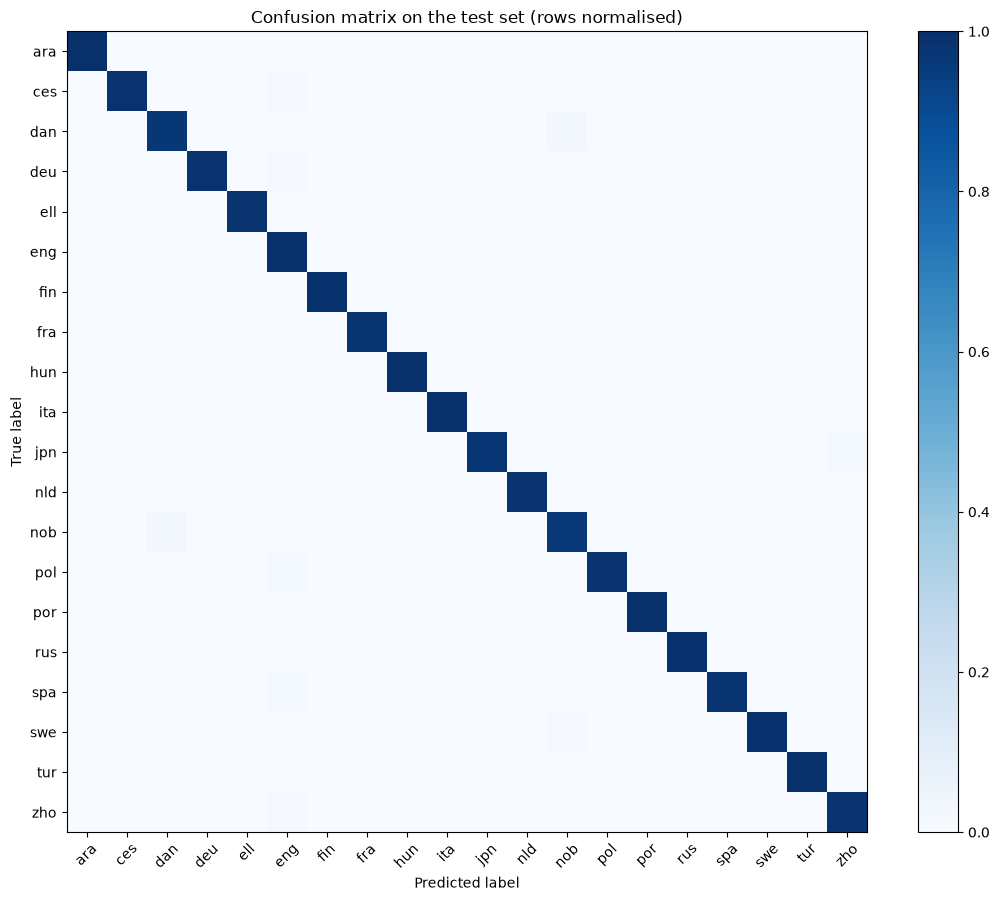

true predicted  count
 nob       dan      6
 dan       nob      5
 pol       eng      3
 spa       eng      3
 jpn       zho      3
 ces       eng      2
 zho       eng      2
 deu       eng      2
 swe       nob      2
 nld       eng      1

true fra / pred nld: (en) Jeffrey S Dome, Vicki Huff, Wilms Tumor Overview In GeneTests: Medical Genetics Information Resource (database online). Copyright, University of 
true fin / pred ces: Esityksen taustalla Melodifestivalenissa nähtyä uusimmalla 3D-tekniikalla toteutettua tikku-ukkoa jouduttiin muokkaamaan, koska se muistutti liian pal
true ell / pred eng: Δημήτρης Κιτσίκης, The Old Calendarists and the Rise of Religious Conservatism in Greece, Εκδ. Center for Traditionalist Orthodox Studies, Etna, Calif
true ces / pred pol: Afghánistán, Alžírsko, Angola, Botswana, Bulharsko, Demokratická republika Kongo, Jemen, Jugoslávie, Kambodža, KLDR, Kuba, Džibuti, Eritrea, Etiopie, 
true deu / pred eng: Edward Duyker: A French Garden in Tasmania. The 

In [33]:
# TODO: Inspect the model's predictions on the different classes

'''
Confusion matrix on the test set (rows normalised), then the most common confusions as a table
and a few misclassified texts to see what went wrong.

Results:
<fill in: which pairs get confused, which languages are perfect>
'''
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

classes = best_model.classes_

fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=classes, normalize='true', cmap='Blues',
                                        xticks_rotation=45, ax=ax, include_values=False)
ax.set_title('Confusion matrix on the test set (rows normalised)')
plt.tight_layout()
plt.show()

# most common confusions
cm = confusion_matrix(y_test, y_pred, labels=classes)
errors = [(classes[i], classes[j], cm[i, j])
          for i in range(len(classes)) for j in range(len(classes))
          if i != j and cm[i, j] > 0]
errors_df = pd.DataFrame(errors, columns=['true', 'predicted', 'count']).sort_values('count', ascending=False)
print(errors_df.head(10).to_string(index=False))

# a few misclassified texts
mask = (y_pred != y_test).values
wrong = test_sub[mask].copy()
wrong['pred'] = y_pred[mask]
print()
for _, row in wrong.head(5).iterrows():
    print(f"true {row['label']} / pred {row['pred']}: {row['text'][:150]}")


---

### 5.1 Interpretability Analysis

Now that you have your best model, it's time to dive deep into understanding how the model makes predictions.

It is important that we can explain and visualise our models to improve task performance. Explainable models help characterise model fairness, transparency, and outcomes.

Let's try to understand what our best-performing logistic regression classification model has learned.

Inspect the 20 most important features for the languages English, Swedish, Norwegian (whichever of `nob`/`nno` you included), and Japanese. Please make sure that the features are named and human-interpretable, not things like "Feat_1". (Hint: if you have used custom feature extractors in your pipeline, you may need to adapt these to make sure that the feature names are maintained.)

📝❓ What is more important, extra features or the outputs of the vectorizer? Please discuss.

We recommend using the [SHAP library](https://shap.readthedocs.io/en/latest/example_notebooks/tabular_examples/linear_models/Sentiment%20Analysis%20with%20Logistic%20Regression.html) as discussed in the [W03 tutorial](https://github.com/Andrian0s/ML4NLP1-2026-Tutorial-Notebooks/blob/main/tutorials_notebooks_in_class_2026/W03_pipeline_gridsearch_shap.ipynb), which shows SHAP for a multi-class linear model.

☝ Note, if you prefer to use another interpretability tool, we will accept answers from any explanation library/method as long as the explanations for the model weights are provided in a structured/clear way.



In [38]:
# shap was installed and imported in the setup cell at the top of the notebook
import shap


eng: top 20 by coefficient
word__was (1.78), word__in (1.38), word__is (1.29), word__are (1.10), word__for (1.01), word__which (1.01), word__the (1.00), word__as (1.00), word__who (0.90), word__born (0.89), script__latin (0.87), word__class (0.86), word__to (0.83), word__democracy (0.78), word__city (0.78), word__and (0.77), word__he (0.74), word__with (0.70), word__acid (0.70), word__at (0.67)

swe: top 20 by coefficient
word__och (3.62), word__är (3.50), word__av (2.21), word__den (1.45), word__på (1.44), word__till (1.31), word__som (1.25), word__med (1.25), word__att (1.06), word__för (1.00), word__från (0.88), word__en (0.86), word__ett (0.79), word__mellom (0.70), word__över (0.70), word__vid (0.68), word__har (0.66), word__var (0.66), word__han (0.64), word__under (0.62)

nob: top 20 by coefficient
word__av (2.83), word__og (2.71), word__ble (2.21), word__til (1.86), word__er (1.74), word__som (1.66), word__seg (1.35), word__det (1.18), word__på (1.17), word__etter (1.08), word

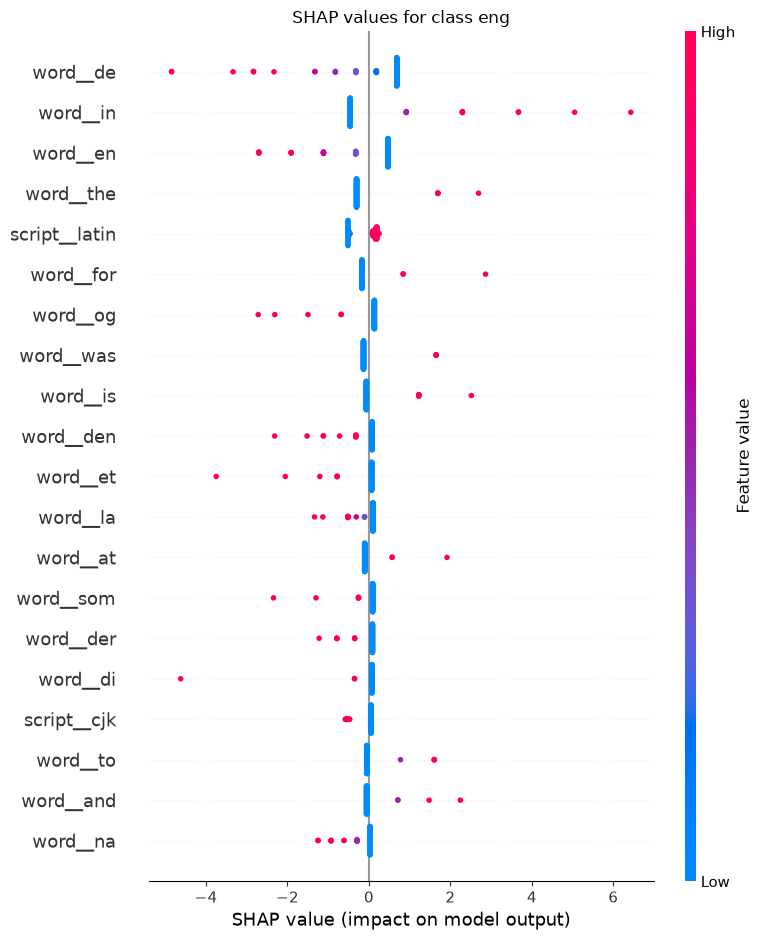

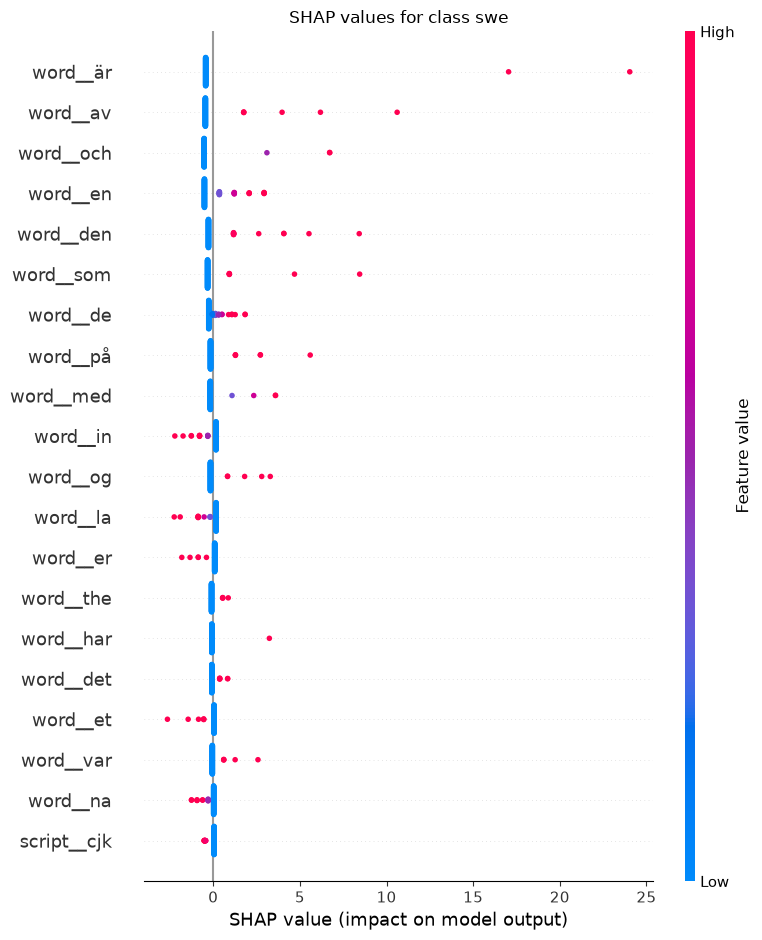

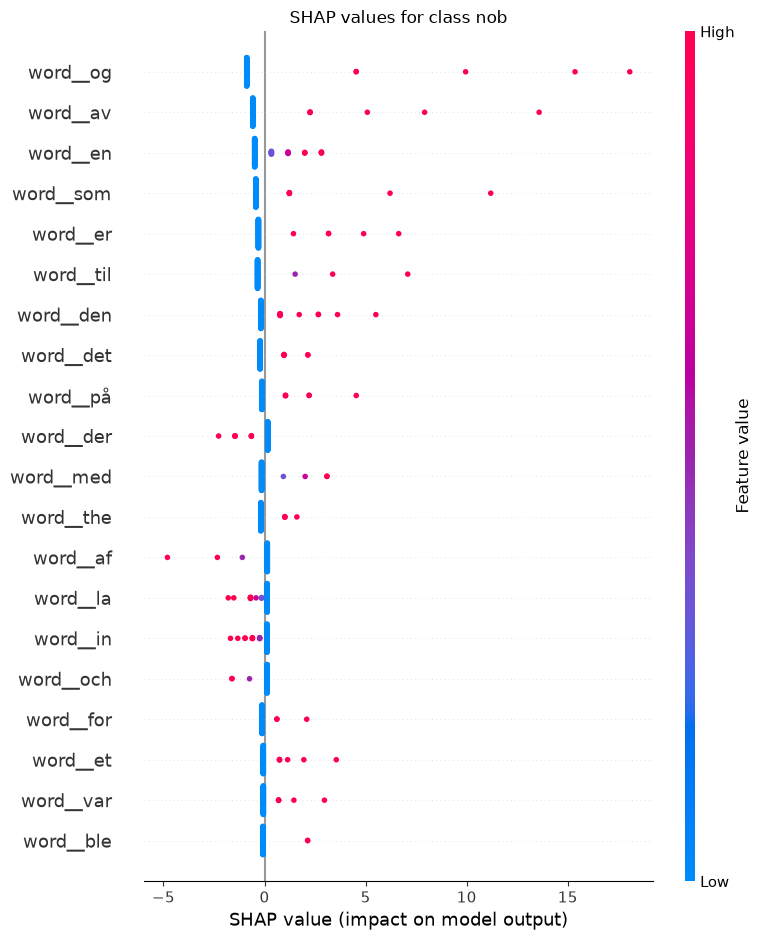

/var/folders/fj/ltzk8qs54bl5xcvjcb85lvlm0000gn/T/ipykernel_56899/1788416368.py:49: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/bdonick/Desktop/uzh/f26/nlp/exercises/ml_nlp/exercise1/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


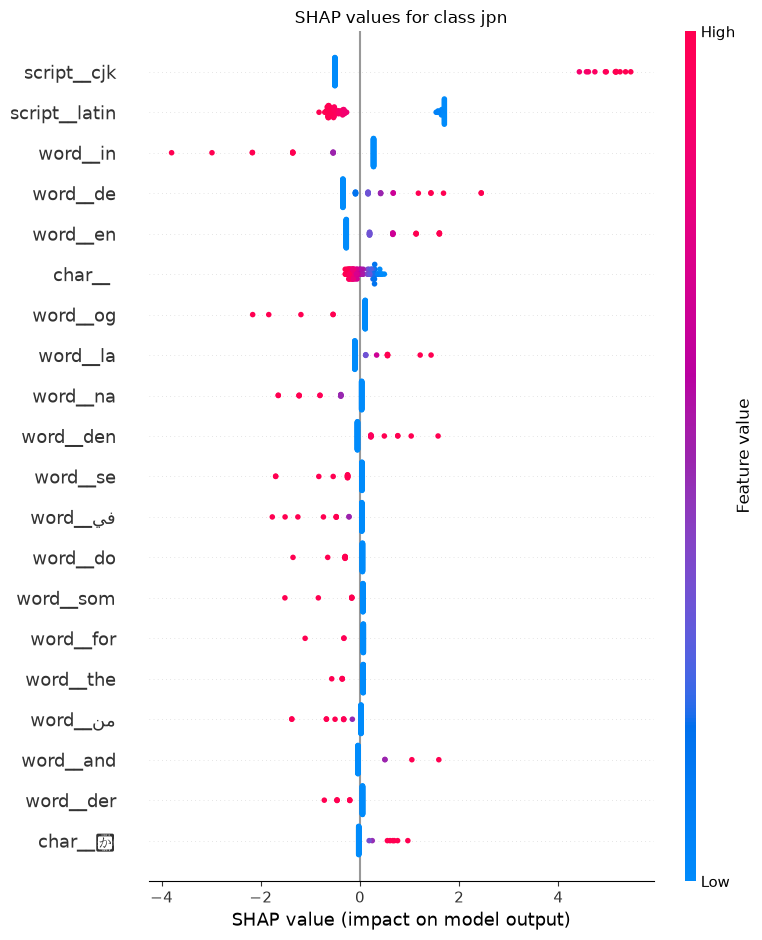

share of total |SHAP| per feature branch:
     char__  word__  script__
eng   0.047   0.906     0.047
swe   0.026   0.956     0.018
nob   0.037   0.946     0.017
jpn   0.156   0.616     0.228


In [39]:
# TODO: Inspect most important features according to the model using SHAP

'''
Top 20 features for eng, swe, nob, jpn.
Two views: raw coefficients (what the model weights) and SHAP values (what actually drives predictions on test texts).
SHAP for a linear model is coef * (x - mean). Computed directly per class instead of shap.LinearExplainer,
the full tensor (docs x 348k features x 20 classes) would need several GB.
Feature names come from the FeatureUnion, the prefix says which branch: char__ / word__ / script__.
Last table: share of total |SHAP| per branch, answers "extra features vs vectorizer".

Results:
<fill in>
'''

features_step = best_model.named_steps['features']
clf = best_model.named_steps['clf']
feature_names = features_step.get_feature_names_out()
classes = list(clf.classes_)
show_langs = ['eng', 'swe', 'nob', 'jpn']

# 1. coefficients: largest positive weight per language
for lang in show_langs:
    k = classes.index(lang)
    top = np.argsort(clf.coef_[k])[::-1][:20]
    print(f'\n{lang}: top 20 by coefficient')
    print(', '.join(f'{feature_names[i]} ({clf.coef_[k, i]:.2f})' for i in top))

# 2. SHAP values on 100 random test texts, background mean from 200 training texts
X_bg = features_step.transform(X_train.sample(200, random_state=42))
X_ex = features_step.transform(X_test.sample(100, random_state=42))
mu = np.asarray(X_bg.mean(axis=0)).ravel()

branches = ['char__', 'word__', 'script__']
branch_mask = {b: np.array([n.startswith(b) for n in feature_names]) for b in branches}
branch_share = {}

for lang in show_langs:
    k = classes.index(lang)
    phi = (X_ex.toarray() - mu) * clf.coef_[k]      # shap values, shape (docs, features)
    importance = np.abs(phi).mean(axis=0)
    top = np.argsort(importance)[::-1][:20]

    branch_share[lang] = {b: importance[branch_mask[b]].sum() / importance.sum() for b in branches}

    exp = shap.Explanation(values=phi[:, top], base_values=np.zeros(len(phi)),
                           data=X_ex[:, top].toarray(), feature_names=list(feature_names[top]))
    shap.plots.beeswarm(exp, max_display=20, show=False)
    plt.title(f'SHAP values for class {lang}')
    plt.tight_layout()
    plt.show()
    del phi

print('share of total |SHAP| per feature branch:')
print(pd.DataFrame(branch_share).T.round(3))


---

### 6.1 Ablation Study

Lastly, we want to conduct a small ablation study to investigate how well our model performs under different conditions.

As a first step, choose the two languages for which the classifier worked best.

Next, re-fit the best model six times, each time reducing the **length** of the texts. To do this, create a custom `TextReducer` class that truncates every text to at most `max_len` characters and include it as a preprocessing step in your pipeline, so that the truncation is applied both when fitting and when predicting. The class should take `max_len` as a hyperparameter that can be set to train the following models:

- Model 1: `max_len = None` (i.e. no truncation!)
- Model 2: `max_len = 500`
- Model 3: `max_len = 250`
- Model 4: `max_len = 150`
- Model 5: `max_len = 100`
- Model 6: `max_len = 50`

Use average accuracy over the cross validation scores for each model to measure performance for each ablation setting.

📝❓ How does reducing the length of the training texts affect the performance of the classifier? And what could be some possible reasons for this?

['ara', 'hun'] max_len=None: 0.9981
['ara', 'hun'] max_len=500: 0.9981
['ara', 'hun'] max_len=250: 0.9981
['ara', 'hun'] max_len=150: 0.9975
['ara', 'hun'] max_len=100: 0.9975
['ara', 'hun'] max_len=50: 0.9975
['dan', 'nob'] max_len=None: 0.9700
['dan', 'nob'] max_len=500: 0.9712
['dan', 'nob'] max_len=250: 0.9631
['dan', 'nob'] max_len=150: 0.9525
['dan', 'nob'] max_len=100: 0.9194
['dan', 'nob'] max_len=50: 0.8787


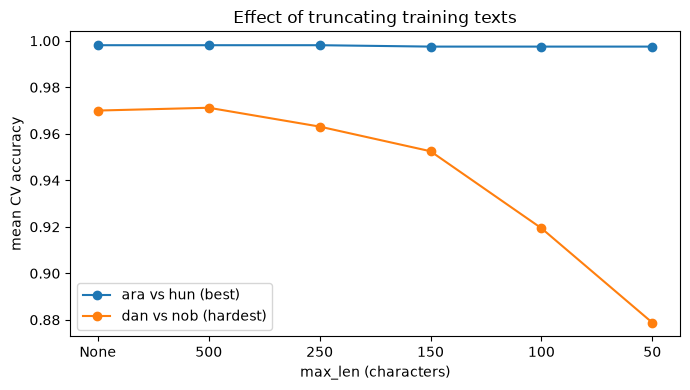

In [40]:
# TODO: Ablation study

'''
Two best languages from the test report: ara (F1 1.000) and hun (0.998).
TextReducer cuts every text to max_len chars, sits in front of the feature union so truncation
happens in fit and predict. Best model params reused, 5-fold CV accuracy per max_len.
Also run on dan vs nob as a contrast, the hardest pair, to see the effect where it matters.

Results:
<fill in>
'''

from sklearn.base import clone


class TextReducer(BaseEstimator, TransformerMixin):
    # truncates every text to at most max_len characters, None = no truncation

    def __init__(self, max_len=None):
        self.max_len = max_len

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if self.max_len is None:
            return list(X)
        return [text[:self.max_len] for text in X]


def ablation(lang_pair, max_lens=(None, 500, 250, 150, 100, 50)):
    mask = y_train.isin(lang_pair)
    X_pair, y_pair = X_train[mask], y_train[mask]
    rows = []
    for max_len in max_lens:
        pipe_abl = Pipeline([('reduce', TextReducer(max_len)), *clone(best_model).steps])
        acc = cross_val_score(pipe_abl, X_pair, y_pair, cv=5, scoring='accuracy').mean()
        rows.append({'max_len': str(max_len), 'cv_accuracy': round(acc, 4)})
        print(f'{lang_pair} max_len={max_len}: {acc:.4f}')
    return pd.DataFrame(rows)


best_pair = ablation(['ara', 'hun'])
hard_pair = ablation(['dan', 'nob'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(best_pair['max_len'], best_pair['cv_accuracy'], marker='o', label='ara vs hun (best)')
ax.plot(hard_pair['max_len'], hard_pair['cv_accuracy'], marker='o', label='dan vs nob (hardest)')
ax.set_xlabel('max_len (characters)')
ax.set_ylabel('mean CV accuracy')
ax.set_title('Effect of truncating training texts')
ax.legend()
plt.tight_layout()
plt.show()


---

## Lab report

📝❓ Write your lab report here, addressing all questions in the notebook. For convenience, the questions are collected below; please keep your answers clearly marked.

### Questions

**1.1 Exploring the training data**

- 📝❓ Do you notice anything that might be challenging for the classification?

  Several of the languages are closely related and share a lot of vocabulary and spelling, especially Danish, Norwegian Bokmål and Swedish. The texts are Wikipedia-style and contain many proper names, numbers and foreign terms (e.g. English titles inside German articles) that carry no information about the language. Text length also varies a lot, from 140 characters up to 40k, so short texts give the model very little to work with.

- 📝❓ How is the data distributed?

  The full dataset has 235 languages with exactly 500 texts per language in train and 500 per language in test (117,500 texts each). It is perfectly balanced, which is why we use accuracy as the main metric.

- 📝❓ Do you think the train/test split is appropriate?

  The test set is representative: same labels, same counts per label and the same text length distribution as train. Two things were still worth fixing. The split is 50/50, which leaves half the data unused for training, and 639 texts appear in both splits, which would inflate test scores. We merged both sets, dropped duplicate texts and resplit 80/20 stratified by label. For our 20-language subset this gives 15,983 training and 3,996 test texts.

**3.2 Best Model Selection**

- 📝❓ What were the hyperparameters of your best-performing model according to cross-validation?

  Solver lbfgs, C = 10, l1_ratio = 0 (L2 penalty), with a mean 3-fold CV accuracy of 98.61%. The runner-up (lbfgs, C = 1) scored 98.60%, well within one standard deviation (about 0.1 points), so the strength of the regularisation barely matters once C is at least 1. Dropping to C = 0.1 costs about 0.3 points. The saga solver was consistently a bit worse (98.3% with L2) and much slower: 40 s per fit for L2 versus 11 s for lbfgs, and 1240 s for L1 with C = 10. L1 with strong regularisation (C = 0.1) was the worst setting at 95.8%, since it zeroes out too many of the 348k features. Overall the tuning only added 0.1 points over the untuned feature pipeline (98.5%); the jump from the CountVectorizer baseline (94.1%) came from the features.

- 📝❓ What is the advantage of grid search cross-validation?

  It evaluates every hyperparameter combination on held-out folds instead of on the training data, so the choice is based on generalisation and not on how well the model fits what it has already seen. The test set stays untouched until the very end, so the final test score is an honest estimate. The per-fold standard deviation also shows how stable each setting is, which a single validation split cannot tell you.

**3.3 Model Evaluation**

- 📝❓ According to standard metrics (e.g. Accuracy, Precision, Recall and F1), how well does your model perform on the held-out test set?

  Test accuracy is 98.65%, essentially identical to the CV estimate of 98.61%, so the model selection did not overfit to the folds. Macro precision, recall and F1 are all 0.987. 17 of the 20 languages have an F1 of 0.98 or higher, and Arabic is perfect. The three weakest classes are English (F1 0.954, precision only 0.917), Norwegian Bokmål (0.965) and Danish (0.968).

**4.1 Error Analysis**

- 📝❓ Where does your model do well and where does it fail?

  The model is near perfect on languages with their own script (Arabic, Greek, Russian) and on languages with distinctive spelling (Hungarian, Finnish, Turkish, Italian all at 0.995 or above). Only 54 of 3,996 test texts are wrong, and they fall into two groups. The largest is Danish versus Norwegian Bokmål, 11 errors in both directions, with 2 more Swedish texts labelled as Bokmål. The second is texts from many different languages (Polish, Spanish, Czech, Chinese, German, Dutch) being labelled as English, 13 errors in total. That is why English has the lowest precision. A few Japanese texts are also labelled as Chinese.

- 📝❓ What are some possible reasons for why it fails in these cases?

  Danish and Bokmål have almost the same orthography and share most of their vocabulary, so character n-grams and word counts give nearly the same picture for both; the differences are a handful of function words and spellings that may not appear in a short text. The English errors are mostly not errors of the model: looking at the misclassified texts, they are bibliography entries or citations written in English inside a Czech, German or Greek article, so the text really is largely English. Japanese to Chinese happens on short texts that are mostly kanji, which are shared with Chinese, with few kana to signal Japanese. Finally, lists of proper names (the Czech example is a list of country names) contain almost no language-specific grammar, so there is little signal left.

**5.1 Interpretability Analysis**

- 📝❓ What is more important, extra features or the outputs of the vectorizer? Please discuss.

  The vectorizer outputs are far more important overall. For English, Swedish and Bokmål, 90 to 96% of the total SHAP mass on test texts comes from the word-count branch, and the top 20 features are all function words: *was, in, is, the* for English, *och, är, av* for Swedish, *av, og, ble, til* for Bokmål. The custom script features contribute under 5% for these three. Japanese is the exception: the share of CJK characters (`script__cjk`) is the single largest coefficient in the whole model (6.5), the script branch carries 23% of the SHAP mass, and the rest is hiragana character n-grams. So the extra features matter when the script itself identifies the language, which is also where the model was already near perfect. For the hard cases, Danish versus Bokmål, they add nothing, because both use the same script and the same marker letters. One caveat: the branches are on different scales. Word counts are raw integers while the char n-grams are L2-normalised TF-IDF values, so the SHAP mass naturally concentrates on the word branch even though adding char n-grams was part of the 4-point jump from the baseline in 2.2. The ranking between branches is therefore indicative rather than exact.

**6.1 Ablation Study**

- 📝❓ How does reducing the length of the training texts affect the performance of the classifier? And what could be some possible reasons for this?

  For the two best languages, Arabic and Hungarian, truncation has almost no effect: CV accuracy goes from 99.81% with full texts to 99.75% at 50 characters. The two use different scripts, so a handful of characters is already enough to tell them apart, and the few remaining errors are texts that are not really in either language (e.g. English citations). To see the effect where it matters we repeated the ablation on the hardest pair, Danish versus Bokmål. There the accuracy is flat down to 500 characters (97.0%), then drops steadily: 96.3% at 250, 95.3% at 150, 91.9% at 100 and 87.9% at 50 characters. The reason is that the model relies on a small set of function words and spellings that differ between the two languages (*af* vs *av*, *ikke* vs *ikke/ikkje*, past-tense forms like *blev* vs *ble*). A 500-character text almost always contains several of these, a 50-character text often contains none, and then the character n-grams and shared vocabulary look the same for both. Since the reducer is applied at training time too, short texts also mean fewer features are seen during fitting, so the model has less to learn from in the first place. Truncating to 500 characters changed nothing, which also shows that most of the useful signal sits in the first few sentences and the very long texts in the data add little.

## Declarations

Please fill in both declarations below by editing this cell (double-click it). Mark the applicable option by replacing ☐ with ☒ (copy the symbol from here: ☒) and complete the text field where required. Your reviewers will check that both declarations are present and completed.

### Contribution declaration

By submitting this work, the group declares that the contributions of the group members were:

approximately equal

If the contributions were not approximately equal, no individual group member needs to be identified.

### Declaration on the use of AI

The group declares that any use of AI-based tools in preparing this work complied with the rules specified for this exercise.

☐ AI-based tools were used in accordance with the rules of the exercise.

If AI-based tools were used, briefly state the tool(s) used and the purpose(s) for which they were used:

Claude Code was used as a coding assistant throughout this notebook. It was used to explain the task requirements and the sklearn API, to draft and debug code cells (e.g. the custom transformers, the grid search set-up and the SHAP computation) which were then reviewed, run and adapted by us. All design decisions, such as the choice of languages, features, hyperparameter grid and the train/test resplit, were discussed with the tool but made by us, and all submitted code and text was checked and understood by the group.